# AERPAW Use Case Demonstration
* This Demonstration showcases the AERPAWEnvironment's specialized funcitonality for use with the AERPAW digial twin
* Includes initialization, visualization, and SNR calculation

## This Environment Provides
* A quick and minimial initialization of the simulation environment
* Straighforward ray-tracing computation of SNR values between all transmitters and receivers in the environment
* All the existing functionality of the general environment

## What's Next
* Incorporating Blender scripting to automatically fetch topology, building, and natural environment data from OpenStreetMaps and OpenTopography for a provided region
* Integrating this functionality directly into the AERPAW environment, to provide an accurate ray-tracing SNR model

2025-09-23 11:49:22.277178: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 11:49:23.989754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758642564.707510   23315 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758642565.792776   23315 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758642568.187938   23315 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

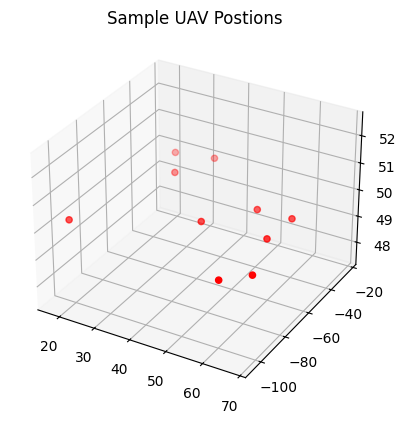

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from AERPAWEnvironment import AERPAWEnv

# Defining the scene, including receivers and transmitters

# Defining a generic UAV for simplicity
generic_uav = {
    "device_type": "tx",
    "mass": 5,
    "efficiency": 0.7,
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([1, 0, 0]),
    "bandwidth": 50,
    "rotor_area": 0.25,
    "signal_power": 3,
    "throughput_capacity": 625000000,
    "battery_capacity": 10000
}

# Configuring some generic uavs with random x and y positions
num_uavs = 10
uavs = []
for i in range(num_uavs):
    uav = dict(generic_uav)
    uav["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 50])
    uavs.append(uav)

# Plotting the positions in 3d
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
plt.title("Sample UAV Postions")
plt.show()

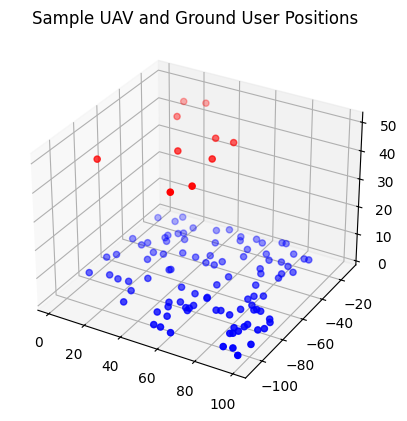

In [2]:
# Defining Generic Ground User

generic_gu = {
    "device_type": "rx",
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "desired_throughput": 375000
}

# Configuring some sample Ground Users
num_gus = 100
gus = []
for i in range(num_gus):
    gu = dict(generic_gu)
    gu["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 2])
    gus.append(gu)

# Plotting UAV and Ground User Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
plt.title("Sample UAV and Ground User Positions")
plt.show()

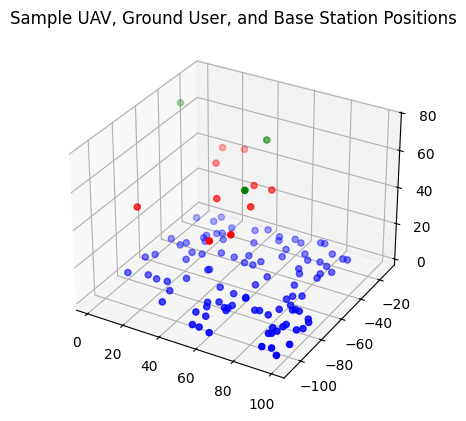

In [3]:
# Generating Sample Base Stations

# Defining a generic base station, then randomizing positions
generic_base_station = {
    "device_type": "rx",
    "position": np.zeros(3),
    "color": np.array([0, 0, 1]),
    "bandwidth": 50,
    "signal_power": 10,
    "throughput_capacity": 625000000,
    "battery_capacity": 1000000
}

# Adding some base stations with random positions
num_bs = 3
bss = []
for i in range(num_bs):
    bs = dict(generic_base_station)
    bs["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 75])
    bss.append(bs)

# Plotting UAV, Ground User, and Base Station Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
axis.scatter([bss[i]["position"][0] for i in range(num_bs)],
           [bss[i]["position"][1] for i in range(num_bs)],
           [bss[i]["position"][2] for i in range(num_bs)],
           color="green")
plt.title("Sample UAV, Ground User, and Base Station Positions")
plt.show()

In [4]:
# Creating the scene with the sample devices
env = AERPAWEnv(scene_path='../data/RaleighUnionSquareStandardReference/raleigh_union_square.xml',
                uavs=uavs, ground_users=gus, base_stations=bss, temperature=300)
env.visualize()

In [5]:
# Computing SNR values between the transmitters and receivers in the scene
print(len(env.getSignalPowers()))

10


In [6]:
snr_dict = env.getSNR(max_depth=2, num_samples=100000, sampling_frequency=1.0, )  # Using default arguments, should be alright
print(f"Number of Recievers: {len(snr_dict)}")
print(f"Number of Transmitters: {len(snr_dict["gu0"])}")

Number of Recievers: 103
Number of Transmitters: 10


I0000 00:00:1758642586.147358   23315 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3922 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/everetttucker471/Documents/RL-AERPAW-DT/src/EnvironmentFramework.py:566: RuntimeWarning: divide by zero encountered in log10
  return 10 * np.log10(signal_power / noise_power)


In [7]:
print(snr_dict["gu0"])

{'uav0': 115.13631043668626, 'uav1': 95.14830148204524, 'uav2': 93.09439987181537, 'uav3': 99.71305663197018, 'uav4': 107.52834053159805, 'uav5': 113.86062120577512, 'uav6': 96.81938539392243, 'uav7': 110.48107300031708, 'uav8': 109.00897291904487, 'uav9': 118.1967106280281}


## Visualization versus AERPAW SNR Data
* To visualize the effectiveness of this model, we visualize its comparison to AERPAW SNR data generated using a path channel model
* This data is taken from the AERPAW team in the context of the AADM Challenge

In [1]:
# Reading data
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from AERPAWEnvironment import AERPAWEnv
sys.path.append("..")

def parseTimeToken(token):
    token = token.strip("]")
    comp = token.split(":")
    return int(comp[0]) * 3600 + int(comp[1]) * 60 + int(float(comp[2]))
    
num_aerpaw_bs = 4
snrs = []
for i in range(num_aerpaw_bs):
    snrs.append({})

with open("../data/aerpaw/vehicle_log.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(" ")
        for i in range(num_aerpaw_bs):
            if f"BS{i + 1}>SNR" in line:
                snrs[i][parseTimeToken(tokens[1])] = float(tokens[-1])

# Converting to pandas Dataframe
df = pd.DataFrame()
df.insert(0, "Time", list(snrs[0].keys()))
for i in range(num_aerpaw_bs):
    df.insert(i + 1, f"LW{i + 1}", list(snrs[i].values()))
print(df)

2025-10-07 15:11:47.247102: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 15:11:47.257149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759864307.268556   20275 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759864307.271992   20275 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759864307.280934   20275 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

      Time        LW1        LW2        LW3        LW4
0    57955 -99.000000 -99.000000 -99.000000 -99.000000
1    57956 -99.000000 -99.000000 -99.000000 -99.000000
2    57957 -99.000000 -99.000000 -99.000000 -99.000000
3    57958 -99.000000 -99.000000 -99.000000 -99.000000
4    57959 -99.000000 -99.000000 -99.000000 -99.000000
..     ...        ...        ...        ...        ...
431  58386  19.168816   0.559805   1.089783  -1.818649
432  58387  19.375866   0.717394  -1.420067  -1.019251
433  58388  21.348263  -1.104740  -0.894634  -1.320980
434  58389  19.693741   0.884892  -0.262821  -2.431139
435  58390  19.506615   0.483650   0.465687  -3.688786

[436 rows x 5 columns]


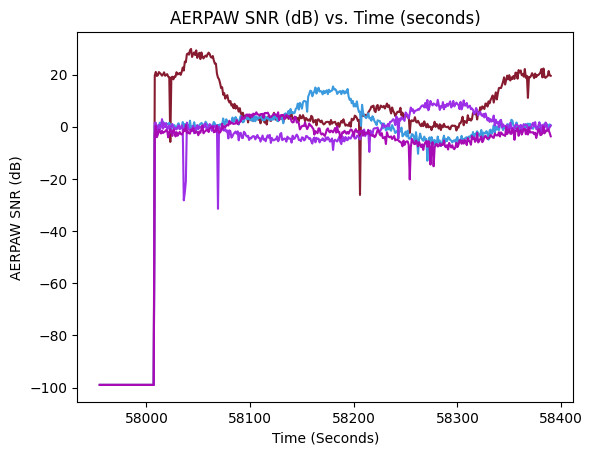

In [2]:
# Plotting the SNR values over time for visualization
for i in range(num_aerpaw_bs):
    plt.plot(df["Time"], df[f"LW{i + 1}"], color=np.random.rand(3))
plt.title("AERPAW SNR (dB) vs. Time (seconds)")
plt.xlabel("Time (Seconds)")
plt.ylabel("AERPAW SNR (dB)")
plt.show()

In [3]:
# Finding the offset to ignore the null snr data
OFFSET = 0
for i in range(100):
    if df["LW1"][i] > 0:
        OFFSET = i
        break
        
print(f"The data really starts at time={OFFSET}")

The data really starts at time=53


### AERPAW Data Inspection
* As you can see from the graph, there is a range before the simulation starts where the SNR is zeroed at -99.0
* Additionally, there are some outlier points where the SNR has a sudden drop
* Other than that, the SNR is fairly consistent over time

In [4]:
# Grabbing UAV position over time

lat = {}
lon = {}
height = {}
with open("../data/aerpaw/vehicle_out.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(",")
        time = parseTimeToken(tokens[-3].split(" ")[1])
        lat[time] = float(tokens[2])
        lon[time] = float(tokens[1])
        height[time] = float(tokens[3])

# Putting the data into local coordinates, and then into the dataframe

R = 6371201  # Radius of Earth at Raleigh, in meters
BASIS = np.array([35.727591, -78.695524, 0])
def latLon(lat_lon, basis):
    """
    Converts a single point to lat/lon, with respect to the basis point
    """
    return np.array([R * np.sin((lat_lon[0] - basis[0]) * np.pi / 180), 
                    R * np.sin((lat_lon[1] - basis[1]) * np.pi / 180), 
                    lat_lon[2]])

# Aligning the coordinates with North / South, so it looks like Google Maps
ALT_COMP = 25  # The ground level in meters used to adjust the altitude of devices in the scene
def alignCoordinate(point):
    return np.array([point[1], point[0], point[2] + ALT_COMP])

positions = np.array([list(lat.values()), list(lon.values()), list(height.values())]).T
print(positions.shape)
for i in range(len(positions)):
    positions[i] = alignCoordinate(latLon(positions[i], BASIS))

df.insert(5, "X", positions[:, 0])
df.insert(6, "Y", positions[:, 1])
df.insert(7, "Height", positions[:, 2])
print(df)

(436, 3)
      Time        LW1        LW2        LW3        LW4          X          Y  \
0    57955 -99.000000 -99.000000 -99.000000 -99.000000 -83.498905 -52.096467   
1    57956 -99.000000 -99.000000 -99.000000 -99.000000 -83.498905 -52.096467   
2    57957 -99.000000 -99.000000 -99.000000 -99.000000 -83.498905 -52.096467   
3    57958 -99.000000 -99.000000 -99.000000 -99.000000 -83.498905 -52.096467   
4    57959 -99.000000 -99.000000 -99.000000 -99.000000 -83.498905 -52.096467   
..     ...        ...        ...        ...        ...        ...        ...   
431  58386  19.168816   0.559805   1.089783  -1.818649 -83.543384 -51.996388   
432  58387  19.375866   0.717394  -1.420067  -1.019251 -83.543384 -51.996388   
433  58388  21.348263  -1.104740  -0.894634  -1.320980 -83.543384 -51.996388   
434  58389  19.693741   0.884892  -0.262821  -2.431139 -83.543384 -51.996388   
435  58390  19.506615   0.483650   0.465687  -3.688786 -83.543384 -52.007508   

     Height  
0    24.983  
1 

In [36]:
# Getting positions of base stations
# offsetting for altitude of environment off the ground

BASE_STATIONS_LATLON = np.array([
    [35.72750947, -78.69595810, 12.973],
    [35.72821305, -78.70090823, 8.947],
    [35.72491205, -78.69190014, 2.345],
    [35.73318358, -78.6983642, 19.345]
])

BASE_STATIONS_XYA = []
for bs in BASE_STATIONS_LATLON:
    BASE_STATIONS_XYA.append(alignCoordinate(latLon(bs, BASIS)))
BASE_STATIONS_XYA = np.array(BASE_STATIONS_XYA)
print(BASE_STATIONS_XYA)

[[ -48.27124053   -9.06600839   37.973     ]
 [-598.71794749   69.17098634   33.947     ]
 [ 402.96755951 -297.89504668   27.345     ]
 [-315.82579427  621.88614126   44.345     ]]


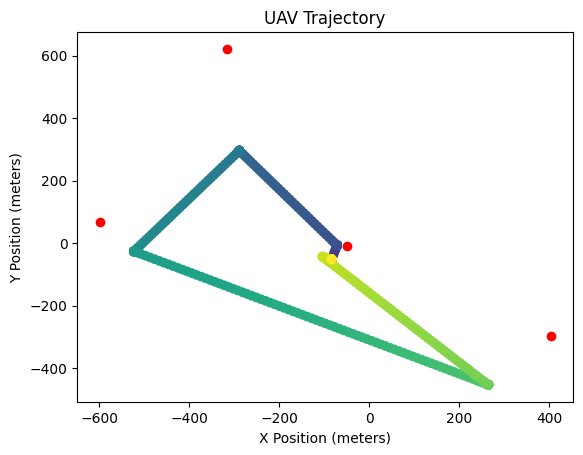

In [37]:
# Map of UAV trajectory and base stations, color-coded by time with lighter as the start

plt.scatter(BASE_STATIONS_XYA[:, 0], BASE_STATIONS_XYA[:, 1], color="red")
plt.scatter(df["X"], df["Y"], c=df["Time"]/max(df["Time"]))
plt.title("UAV Trajectory")
plt.xlabel("X Position (meters)")
plt.ylabel("Y Position (meters)")
plt.show()
# Just need to rotate clockwise 90 degrees to align it with north/south

## Generating Scene
* Now that we have the AERPAW data clearly parsed, we want to generate the same Lake Wheeler environment in the RL-DT framework
* We start by grabbing data from OpenStreetMaps, then instantiate the base stations and single UAV device
* After we have set up the simulated environment, we can move the UAV around the scene in the same pattern, and record the SNR values to each base station

In [38]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
# Instantiating the scene using the minimial AERPAWEnvironment
from AERPAWEnvironment import AERPAWEnv

"""
We use the following material substitutions in the XML file:
<!-- Sionna Material Subsitutions:
	    mat-wall -> itu-concrete
		mat-roof -> itu-plywood
		mat-vegetation -> itu-medium_dry_ground
		mat-roads_residential -> itu-concrete
		mat-roads_service -> itu-concrete
		mat-water -> itu-wet_ground
		mat-roads_primary -> itu-concrete
		mat-paths_footway -> itu-concrete
		mat-roads_track -> itu-concrete
		mat-forest -> itu-medium_dry_ground 
		mat-paths_steps -> itu-concrete
	-->
"""

# Three different degrees of detail, including 100%, 25%, and 4%
# More detail = more memory consumption, and sometimes your kernel will die
terrain_100 = "../data/aerpaw/LakeWheelerTerrain/lake_wheeler_road_aerpaw.xml"
terrain_025 = "../data/aerpaw/LakeWheelerTerrain25/lake_wheeler_road_aerpaw.xml"
terrain_004 = "../data/aerpaw/LakeWheelerTerrain04/lake_wheeler_road_aerpaw.xml"
realistic = "../data/LakeWheelerRealistic/lake_wheeler_road_aerpaw.xml"
buildings = "../data/aerpaw/LakeWheelerBuildings/lake_wheeler_road_aerpaw.xml"

# Test visualization without any scene objects
test_env = AERPAWEnv(scene_path=terrain_004,
                uavs={}, ground_users={}, base_stations={}, temperature=300)
test_env.visualize()

In [1]:
# We're leaving in only the parameters that are relavent to this experiment, the other ones are left to defaults
BS_SIGNAL_POWER = 2
BS_BANDWIDTH = 3300
UAV_SIGNAL_POWER = 0.5
UAV_BANDWIDTH = 3300

base_stations = [
    {
    "device_type": "tx",
    "position": BASE_STATIONS_XYA[0],
    "color": np.array([0, 1, 0]),
    "bandwidth": BS_BANDWIDTH,
    "signal_power": BS_SIGNAL_POWER},
    {
    "device_type": "tx",
    "position": BASE_STATIONS_XYA[1],
    "color": np.array([0, 1, 0]),
    "bandwidth": BS_BANDWIDTH,
    "signal_power": BS_SIGNAL_POWER},
    {
    "device_type": "tx",
    "position": BASE_STATIONS_XYA[2],
    "color": np.array([0, 1, 0]),
    "bandwidth": BS_BANDWIDTH,
    "signal_power": BS_SIGNAL_POWER},
    {
    "device_type": "tx",
    "position": BASE_STATIONS_XYA[3],
    "color": np.array([0, 1, 0]),
    "bandwidth": BS_BANDWIDTH,
    "signal_power": BS_SIGNAL_POWER
    }
]

uav = [
    {
    "device_type": "rx",
    "position": np.array([df["X"][0], df["Y"][0], df["Height"][0]]),
    "velocity": np.zeros(3),
    "color": np.array([0, 0, 1]),
    "bandwidth": UAV_BANDWIDTH,
    "signal_power": UAV_SIGNAL_POWER
    }
]

env = AERPAWEnv(scene_path=buildings, uavs=uav, ground_users={}, base_stations=base_stations, temperature=300)
env.visualize()

NameError: name 'BASE_STATIONS_XYA' is not defined

In [49]:
snrs = env.getSNR(max_depth=1, num_samples=100000, sampling_frequency=1.0, mode="gpu", los=False, reverse=False)

In [50]:
print(snrs)

{'uav0': {'bs0': -5.500667457647255, 'bs1': -inf, 'bs2': -inf, 'bs3': -inf}}


In [51]:
MAX_DEPTH = 1
NUM_SAMPLES = 100000

snr_computed = [[], [], [], []]
plot = False

for i in range(OFFSET, len(df)):
    print(f"Computing {i}")
    position = np.array([df["X"][i], df["Y"][i], df["Height"][i]])
    env.moveAbsUAV(0, position, np.zeros(3))
    
    # Computing and storing the SNR values
    snrs = env.getSNR(max_depth=MAX_DEPTH, num_samples=NUM_SAMPLES, 
                      sampling_frequency=1.0, mode="gpu", los=False, 
                      reverse=False)
    
    # Adding to the arrays
    for j in range(num_aerpaw_bs):
        snr_computed[j].append(snrs["uav0"][f'bs{j}'])
    
    np.savetxt("../data/aerpaw/EnvironmentComparison/snr_computed.csv", np.array(snr_computed), delimiter=',')
    
    if plot:
        # Plotting the current state
        plt.scatter(position[0], position[1], color="green")
        plt.scatter(BASE_STATIONS_XYA[:, 0], BASE_STATIONS_XYA[:, 1], color="red")
        plt.title(f"Environment State at Time {i + 1}")
        plt.xlabel("X Position (meters)")
        plt.ylabel("Y Position (meters)")
        plt.savefig(f"../data/aerpaw/EnvironmentComparison/state{i}.png")

print(np.array(snr_computed).astype(np.float64))

Computing 53
Computing 54
Computing 55
Computing 56
Computing 57
Computing 58
Computing 59
Computing 60
Computing 61
Computing 62
Computing 63
Computing 64
Computing 65
Computing 66
Computing 67
Computing 68
Computing 69
Computing 70
Computing 71
Computing 72
Computing 73
Computing 74
Computing 75
Computing 76
Computing 77
Computing 78
Computing 79
Computing 80
Computing 81
Computing 82
Computing 83
Computing 84
Computing 85
Computing 86
Computing 87
Computing 88
Computing 89
Computing 90
Computing 91
Computing 92
Computing 93
Computing 94
Computing 95
Computing 96
Computing 97
Computing 98
Computing 99
Computing 100
Computing 101
Computing 102
Computing 103
Computing 104
Computing 105
Computing 106
Computing 107
Computing 108
Computing 109
Computing 110
Computing 111
Computing 112
Computing 113
Computing 114
Computing 115
Computing 116
Computing 117
Computing 118
Computing 119
Computing 120
Computing 121
Computing 122
Computing 123
Computing 124
Computing 125
Computing 126
Computing 1

In [52]:
import numpy as np
import matplotlib.pyplot as plt
snr = np.loadtxt("../data/aerpaw/EnvironmentComparison/snr_computed.csv", delimiter=',')
snr = np.maximum(snr, -10)
print(snr)

[[ -5.52240603  -5.52240603  -5.52240603 ...  -5.78325217  -5.5393038
   -5.52528859]
 [-10.         -10.         -10.         ... -10.         -10.
  -10.        ]
 [-10.         -10.         -10.         ... -10.         -10.
  -10.        ]
 [-10.         -10.         -10.         ... -10.         -10.
  -10.        ]]


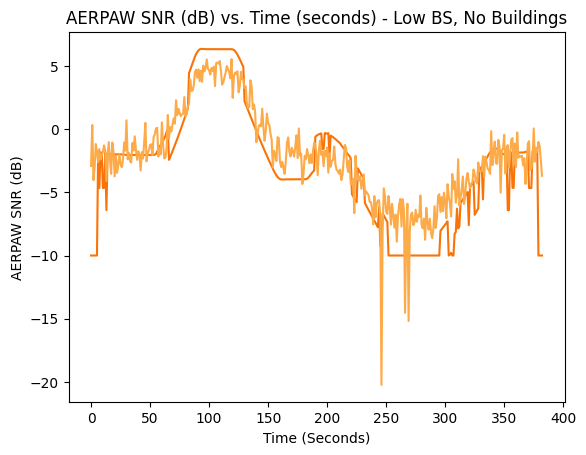

In [53]:
computed_colors = ["xkcd:green", "xkcd:blue", "xkcd:red", "xkcd:orange"]
aerpaw_colors = ["xkcd:light green", "xkcd:light blue", "xkcd:light red", "xkcd:light orange"]

for i in range(3, 4):
    plt.plot(snr[i], color=computed_colors[i])
for i in range(3, 4):
    plt.plot(df[f"LW{i + 1}"][OFFSET:].reset_index(drop=True), color=aerpaw_colors[i])
plt.title("AERPAW SNR (dB) vs. Time (seconds) - Low BS, No Buildings")
plt.xlabel("Time (Seconds)")
plt.ylabel("AERPAW SNR (dB)")
plt.show()